# ML - Final Project
## Clustering
**Project:** Multilingual Language Identification System

**Group Members:** 
1. Seyyed Sina Alizadeh Tabatabai - 810101477
2. Majid Sadeghinejad - 810101459
3. Matin Shiasi - 810101453

## 1. Introduction
In this phase, we analyze the dataset using unsupervised learning. Unlike classification, where we provided the model with "correct" answers (labels), here we let the algorithms find natural groupings within the data based solely on the extracted feature vectors.

**Objectives:**
1.  Exploratory Analysis: Determine if the audio features (MFCCs, Chroma, Centroid) naturally form distinct clusters.
2.  Algorithm Implementation: Apply K-Means (centroid-based) and Hierarchical Clustering (connectivity-based).
3.  Optimization: Use the Elbow Method and Silhouette Score to mathematically determine the optimal number of clusters (k).
4.  Visualization: Use Dimensionality Reduction techniques (t-SNE) to visualize high-dimensional data in 2D space.

This analysis helps us understand the intrinsic structure of the data: Do Spanish and Italian sound similar mathematically? Does Korean form a distinct island?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

sns.set_style("whitegrid")

DATA_FILE = '../Output/CSV/extracted_features.csv'
SCALER_FILE = '../Output/PKL/scaler.pkl'
RANDOM_STATE = 42

print("Libraries imported.")


Libraries imported.


## 2. Data Loading and Preprocessing
We load the same feature set used in classification.

**Critical Step:** We must scale the data. Clustering algorithms calculate distances (Euclidean). If one feature (e.g., Spectral Centroid = 2000Hz) has a much larger range than another (e.g., MFCC = 20), the algorithm will be biased entirely toward the larger feature.

We use the pre-fitted StandardScaler from the previous notebook to ensure consistency.


In [2]:
df = pd.read_csv(DATA_FILE)

X = df.drop(columns=['filename', 'label', 'gender', 'type'])
y_true = df['label']

scaler = joblib.load(SCALER_FILE)

X_scaled = scaler.transform(X)

print(f"Data Loaded and Scaled. Shape: {X_scaled.shape}")

Data Loaded and Scaled. Shape: (1440, 39)


## 3. Determining the Optimal Number of Clusters (k)
We typically expect k=4 (since we have 4 languages), but the data might tell a different story (e.g., Male vs Female, or Romance vs Non-Romance languages). We use two methods to find the mathematical optimum.

### 3.1 The Elbow Method
We run K-Means for k=1 to 10 and calculate the Inertia (Sum of Squared Distances within clusters). As k increases, inertia decreases. The "Elbow" is the point of diminishing returns where adding a new cluster doesn't significantly improve compactness.


k=1: Inertia = 56676.5694
k=2: Inertia = 40935.4679
k=3: Inertia = 35066.0294
k=4: Inertia = 30593.3061
k=5: Inertia = 27037.6068
k=6: Inertia = 24548.8339
k=7: Inertia = 22751.2327
k=8: Inertia = 21140.2456
k=9: Inertia = 19650.1578
k=10: Inertia = 18553.4298


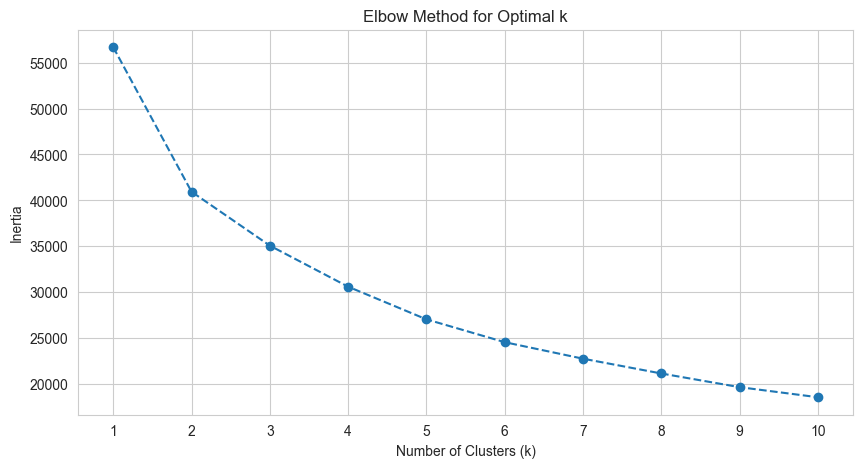

The Elbow is in k = 2


In [3]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    print(f"k={k}: Inertia = {kmeans.inertia_:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

print("The Elbow is in k = 2")

### 3.2 Silhouette Analysis
The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation).
*   Range: -1 to +1.
*   Interpretation: High values indicate well-separated clusters. We look for the k that maximizes this score.


k=2: Silhouette Score = 0.2684
k=3: Silhouette Score = 0.2045
k=4: Silhouette Score = 0.2281
k=5: Silhouette Score = 0.2522
k=6: Silhouette Score = 0.2699
k=7: Silhouette Score = 0.2778
k=8: Silhouette Score = 0.2756
k=9: Silhouette Score = 0.2723
k=10: Silhouette Score = 0.2888


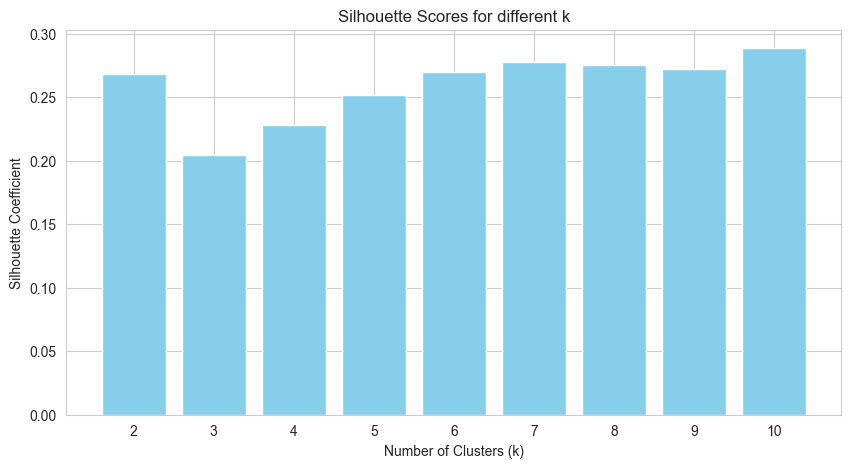


Optimal k based on Silhouette Score: 10


In [4]:
silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(10, 5))
plt.bar(k_range_sil, silhouette_scores, color='skyblue')
plt.title('Silhouette Scores for different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Coefficient')
plt.xticks(k_range_sil)
plt.show()

optimal_k = k_range_sil[np.argmax(silhouette_scores)]
print(f"\nOptimal k based on Silhouette Score: {optimal_k}")


## 4. Clustering Implementation
We will now apply the algorithms using k=4 to align with our known labels for comparison.

### 4.1 K-Means Clustering
Partitions data into k distinct non-overlapping subgroups. It minimizes the within-cluster variance.


In [5]:
CHOSEN_K = 4

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['kmeans_cluster'] = kmeans_labels
print("K-Means clustering complete.")


K-Means clustering complete.


### 4.2 Hierarchical Clustering (Agglomerative)
Builds a hierarchy of clusters. We use the Ward linkage method, which minimizes the variance of the clusters being merged. This is often more robust than K-Means for non-spherical shapes.


In [6]:
agg_clustering = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

df['agg_cluster'] = agg_labels
print("Hierarchical clustering complete.")


Hierarchical clustering complete.


## 5. Visualization (Dimensionality Reduction)
Our data has 39 dimensions (features). To visualize it, we must compress it into 2 dimensions while preserving structure.

**t-SNE (t-Distributed Stochastic Neighbor Embedding)**

Non-linear technique. It preserves local relationships (neighbors).
*   Use case: Visualizing distinct clusters that might be non-linearly separable.


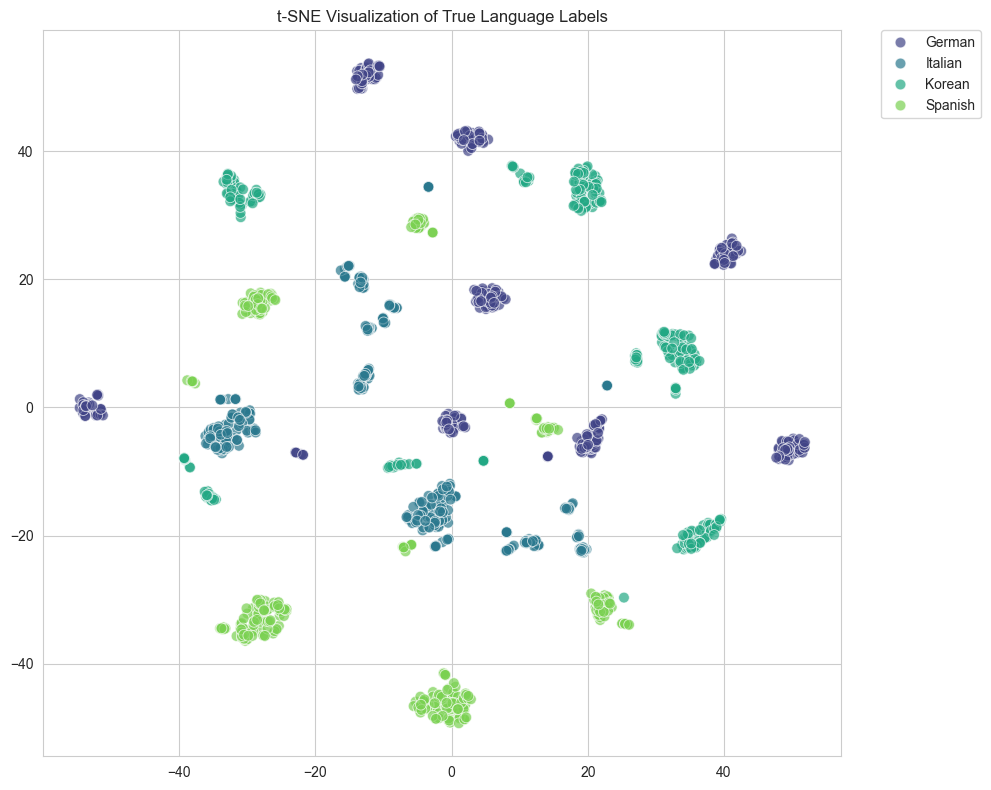

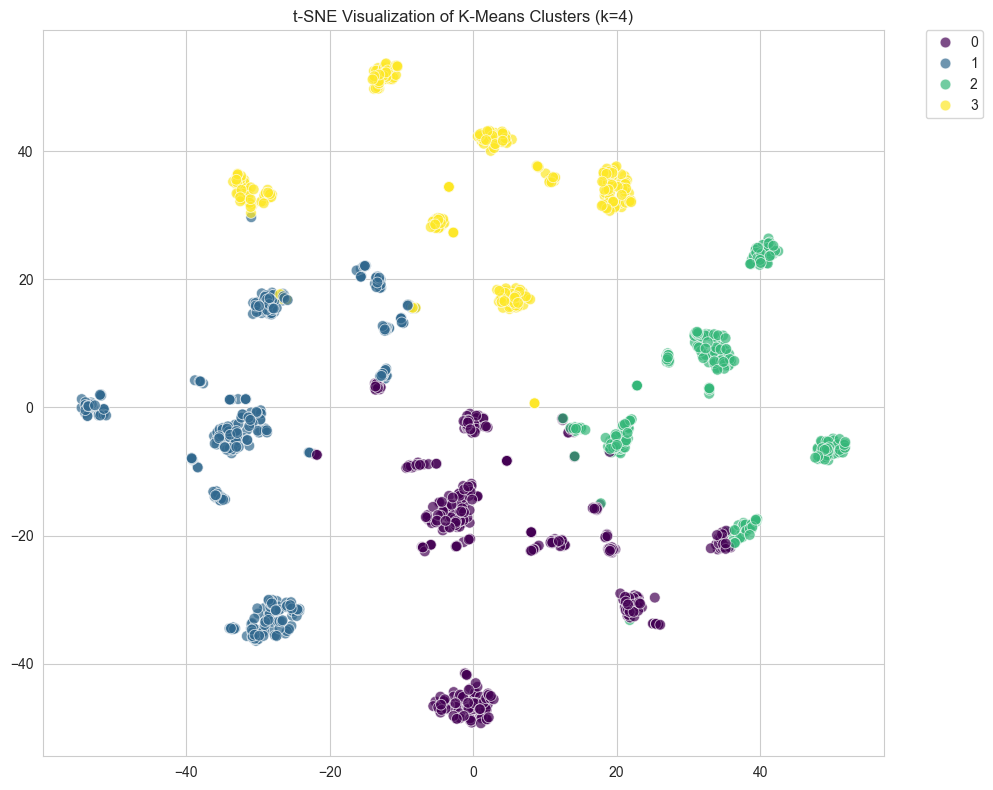

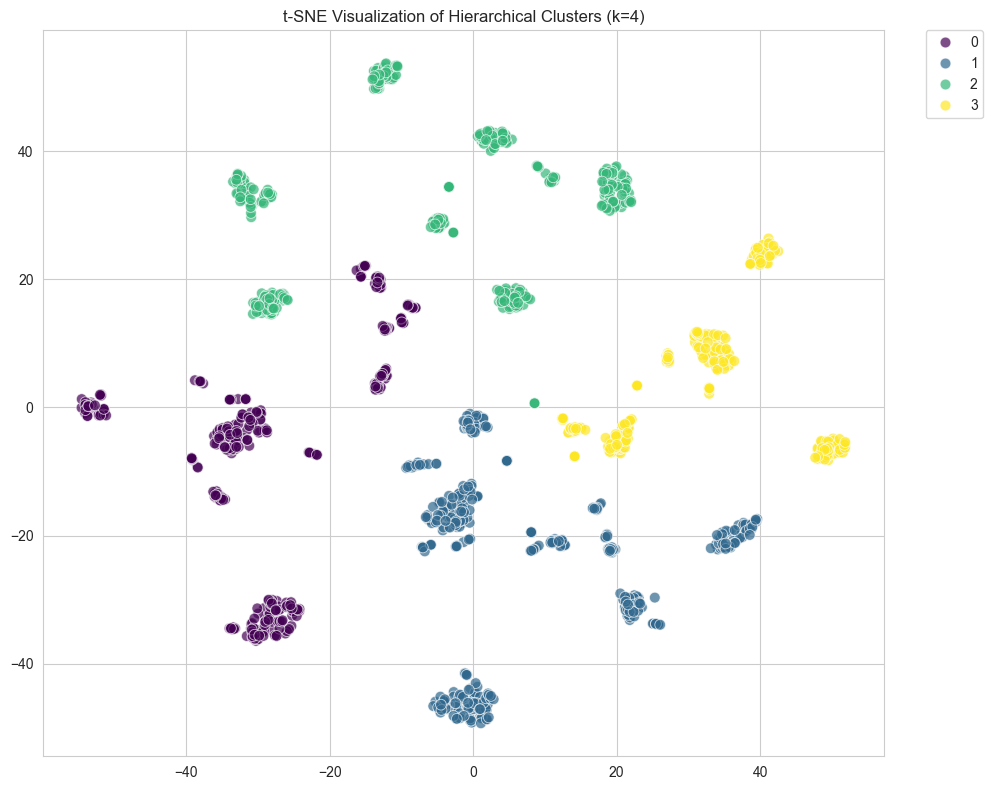

In [7]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

def plot_clusters(data_2d, labels, title):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=data_2d[:,0], y=data_2d[:,1], hue=labels, palette='viridis', s=60, alpha=0.7)
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.tight_layout()
    plt.show()

plot_clusters(X_tsne, y_true, 't-SNE Visualization of True Language Labels')
plot_clusters(X_tsne, df['kmeans_cluster'], f't-SNE Visualization of K-Means Clusters (k={CHOSEN_K})')
plot_clusters(X_tsne, df['agg_cluster'], f't-SNE Visualization of Hierarchical Clusters (k={CHOSEN_K})')



## 6. Analysis and Saving
We verify how "pure" our clusters are. Ideally, Cluster 0 would contain mostly German, Cluster 1 mostly Korean, etc.
We calculate a simple crosstab to see the composition of each cluster.


In [30]:
print("Cluster Composition (Rows=True Label, Cols=Predicted Cluster):\n")
crosstab_kmeans = pd.crosstab(df['label'], df['kmeans_cluster'])
crosstab_agglom = pd.crosstab(df['label'], df['agg_cluster'])
print(crosstab_kmeans,'\n')
print(crosstab_agglom)

df.to_csv('../Output/CSV/clustering_results.csv', index=False)
print("\nClustering results saved to 'clustering_results.csv'.")


Cluster Composition (Rows=True Label, Cols=Predicted Cluster):

kmeans_cluster    0    1    2    3
label                             
German           42   43  138  137
Italian         172  169    8   11
Korean           56   31  124  149
Spanish         160  147   17   36 

agg_cluster    0    1    2    3
label                          
German        46   35  137  142
Italian      188  158    7    7
Korean        30   90  150   90
Spanish      100  150   83   27

Clustering results saved to 'clustering_results.csv'.
